# Identifying Entities in Healthcare Data

## Workspace set up: Import and Install useful packages.

In [3]:
!pip install pycrf
!pip install sklearn-crfsuite

# Collections and Itertools
from collections import Counter, defaultdict
from itertools import chain

# CSV Handling
import csv

# Data Handling and Visualization
import pandas as pd
import matplotlib.pyplot as plt

# NLP and CRF libraries
import spacy
import sklearn_crfsuite
from sklearn_crfsuite import metrics

# Scikit-learn metrics
from sklearn.metrics import f1_score, classification_report

# Load the small English language model in spaCy for NLP tasks like tokenization, POS tagging, and named entity recognition
model = spacy.load("en_core_web_sm")

##Data Preprocessing

The dataset provided is in the form of one word per line. Let's understand the format of data below:
- Suppose there are *x* words in a sentence, then there will be *x* continuous lines with one word in each line. 
- Further, the two sentences are separated by empty lines. The labels for the data follow the same format.

**We need to pre-process the data to recover the complete sentences and their labels.**


### Construct the proper sentences from individual words and print the 5 sentences.

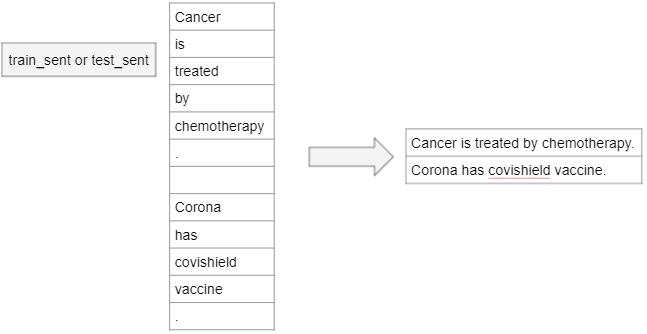

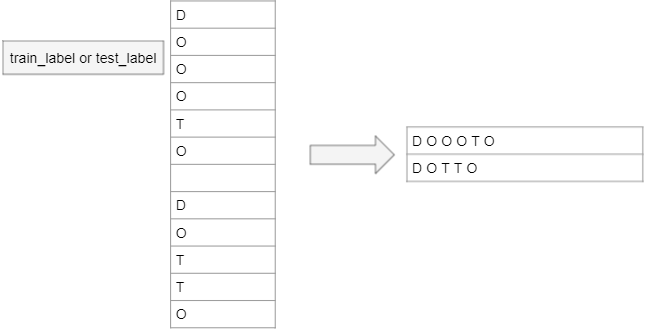

## Reading and Processing the Data

In [8]:
# Function to load sentence and label files for token-level classification tasks
def load_data(token_file, label_file):
    """
    Loads tokenized sentences and their corresponding labels from two files.

    Each sentence and its labels are separated by blank lines.
    Each token and its label are on corresponding lines in the two files.

    Args:
        token_file (str): Path to the file containing tokens.
        label_file (str): Path to the file containing labels.

    Returns:
        tuple: A pair (sentences, labels) where:
            - sentences is a list of lists, each inner list is a sentence of tokens.
            - labels is a list of lists, each inner list contains the corresponding labels.
    """

    sentences = []        # To store all sentences
    labels = []           # To store all corresponding label sequences
    current_tokens = []   # Temporarily holds tokens of the current sentence
    current_labels = []   # Temporarily holds labels of the current sentence

    # Open both files simultaneously
    with open(token_file, 'r') as tf, open(label_file, 'r') as lf:
        for token_line, label_line in zip(tf, lf):
            token = token_line.strip()
            label = label_line.strip()

            # Blank lines indicate the end of a sentence
            if token == '' or label == '':
                if current_tokens:
                    sentences.append(current_tokens)
                    labels.append(current_labels)
                    current_tokens = []
                    current_labels = []
            else:
                # Add token and label to current sentence
                current_tokens.append(token)
                current_labels.append(label)

        # Add any final sentence not followed by a blank line at the end of file
        if current_tokens:
            sentences.append(current_tokens)
            labels.append(current_labels)

    return sentences, labels


In [9]:
# File paths
train_sent_file = 'train_sent'
train_label_file = 'train_label'
test_sent_file = 'test_sent'
test_label_file = 'test_label'

# Load the data
train_sentences, train_labels = load_data(train_sent_file, train_label_file)
test_sentences, test_labels = load_data(test_sent_file, test_label_file)

total_train_tokens = sum(len(sent) for sent in train_sentences)
total_test_tokens = sum(len(sent) for sent in test_sentences)

# Quick checks to verify data
print(f"Training samples count: {len(train_sentences)}")
print(f"Train label count: {len(train_labels)}")
print(f"Testing samples count: {len(test_sentences)}")
print(f"Test label count: {len(test_labels)}")
print(f"Total tokens in training data: {total_train_tokens}")
print(f"Total tokens in testing data: {total_test_tokens}")

Training samples count: 2599
Train label count: 2599
Testing samples count: 1056
Test label count: 1056
Total tokens in training data: 45902
Total tokens in testing data: 18618


In [10]:
# Printing 5 sentences.
for i in range(5):
    print(f"\nExample {i+1}")
    # Join tokens into a full sentence string
    full_sentence = ' '.join(train_sentences[i])
    print("Full sentence:", full_sentence)
    print("Tokens:", train_sentences[i])
    print("Labels:", train_labels[i])



Example 1
Full sentence: All live births > or = 23 weeks at the University of Vermont in 1995 ( n = 2395 ) were retrospectively analyzed for delivery route , indication for cesarean , gestational age , parity , and practice group ( to reflect risk status )
Tokens: ['All', 'live', 'births', '>', 'or', '=', '23', 'weeks', 'at', 'the', 'University', 'of', 'Vermont', 'in', '1995', '(', 'n', '=', '2395', ')', 'were', 'retrospectively', 'analyzed', 'for', 'delivery', 'route', ',', 'indication', 'for', 'cesarean', ',', 'gestational', 'age', ',', 'parity', ',', 'and', 'practice', 'group', '(', 'to', 'reflect', 'risk', 'status', ')']
Labels: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

Example 2
Full sentence: The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )
Token

### Count the number of sentences in the processed train and test dataset 

In [12]:
# Count sentences in train and test sets
num_train_sentences = len(train_sentences)
num_test_sentences = len(test_sentences)

print(f"Number of sentences in training data: {num_train_sentences}")
print(f"Number of sentences in test data: {num_test_sentences}")


Number of sentences in training data: 2599
Number of sentences in test data: 1056


### Count the number of lines of labels in the processed train and test dataset.

In [14]:
# Count total number of label lines (tokens) in train and test labels
total_train_label_lines = sum(len(labels) for labels in train_labels)
total_test_label_lines = sum(len(labels) for labels in test_labels)

print(f"Total number of label lines in training data: {total_train_label_lines}")
print(f"Total number of label lines in testing data: {total_test_label_lines}")


Total number of label lines in training data: 45902
Total number of label lines in testing data: 18618


## Concept Identification

We will first explore what are the various concepts present in the dataset. For this, we will use PoS Tagging. 


### Extract those tokens which have NOUN or PROPN as their PoS tag and find their frequency

In [17]:
# Combine train and test sentences
all_sentences = train_sentences + test_sentences

# Convert list of tokens to full sentences (strings)
all_text = [" ".join(sentence) for sentence in all_sentences]

# Counter to keep track of nouns and proper nouns
noun_counter = Counter()

# Use the already loaded spaCy model (named `model`)
for doc in model.pipe(all_text, disable=["ner", "parser"]):
    for token in doc:
        if token.pos_ in ("NOUN", "PROPN"):
            noun_counter[token.text.lower()] += 1  # normalize to lowercase

# Get the 25 most common noun/proper noun concepts
top_concepts = noun_counter.most_common(25)


### Print the top 25 most common tokens with NOUN or PROPN PoS tags

In [19]:
# Display results of top 25 most common tokens with NOUN or PROPN PoS tags
print("Top 25 nouns and proper nouns with their frequencies:\n")
for word, freq in top_concepts:
    print(f"{word}: {freq}")


Top 25 nouns and proper nouns with their frequencies:

patients: 507
treatment: 304
%: 247
cancer: 211
therapy: 177
study: 174
disease: 149
cell: 142
lung: 118
results: 116
group: 111
effects: 99
gene: 91
chemotherapy: 91
use: 87
effect: 82
women: 81
analysis: 76
risk: 74
surgery: 73
cases: 72
p: 72
rate: 68
survival: 67
response: 66


## Defining features for CRF





In [21]:
# Function to Defining features for CRF
def get_features_for_sentence(sentence, nlp_model):
    """
    Extract token-level features from a sentence using a spaCy model.
    
    Args:
        sentence (list of str): A list of words (tokens) forming the sentence.
        nlp_model (spacy.lang): A loaded spaCy language model with a tagger pipeline.

    Returns:
        list of dict: A list where each dict contains features for a token.
    """
    from spacy.tokens import Doc
    
    # Create a spaCy Doc object from the list of tokens
    doc = Doc(nlp_model.vocab, words=sentence)
    
    # Run the tagger pipeline component to assign POS tags and morph features
    nlp_model.get_pipe("tagger")(doc)
    
    features = []
    
    # Iterate over each token in the Doc to extract features
    for i, token in enumerate(doc):
        # Basic token-level features
        feat = {
            'word': token.text,               # Original token text
            'lower': token.text.lower(),     # Lowercase form
            'prefix': token.text[:3],        # First 3 characters
            'suffix': token.text[-3:],       # Last 3 characters
            'pos': token.pos_,               # Coarse-grained POS tag
            'tag': token.tag_,               # Fine-grained POS tag
            'shape': token.shape_,           # Shape pattern of the token (e.g. Xxxx, dddd)
            'lemma': token.lemma_,           # Lemma (base form)
            'is_title': token.is_title,      # Is token titlecased?
            'is_upper': token.is_upper,      # Is token all uppercase?
            'is_digit': token.is_digit,      # Is token a digit?
            'bias': 1.0                      # Bias term for feature weighting
        }

        # Features for the previous token, if it exists
        if i > 0:
            feat.update({
                'prev_word': doc[i - 1].text,      # Previous token text
                'prev_pos': doc[i - 1].pos_,       # Previous token POS tag
                'prev_shape': doc[i - 1].shape_    # Previous token shape
            })
        else:
            # Beginning of sentence indicator
            feat['BOS'] = True

        # Features for the next token, if it exists
        if i < len(doc) - 1:
            feat.update({
                'next_word': doc[i + 1].text,      # Next token text
                'next_pos': doc[i + 1].pos_,       # Next token POS tag
                'next_shape': doc[i + 1].shape_    # Next token shape
            })
        else:
            # End of sentence indicator
            feat['EOS'] = True

        # Append this token's features to the list
        features.append(feat)

    return features


## Getting the features

### Write a code/function to get the features for a sentence

In [24]:
# Write a code to get features for a sentence.
sentence = train_sentences[0]  # example sentence
features = get_features_for_sentence(sentence, model)

print("Features for the sentence:")
for f in features:
    print(f)

Features for the sentence:
{'word': 'All', 'lower': 'all', 'prefix': 'All', 'suffix': 'All', 'pos': '', 'tag': 'NN', 'shape': 'Xxx', 'lemma': '', 'is_title': True, 'is_upper': False, 'is_digit': False, 'bias': 1.0, 'BOS': True, 'next_word': 'live', 'next_pos': '', 'next_shape': 'xxxx'}
{'word': 'live', 'lower': 'live', 'prefix': 'liv', 'suffix': 'ive', 'pos': '', 'tag': 'NN', 'shape': 'xxxx', 'lemma': '', 'is_title': False, 'is_upper': False, 'is_digit': False, 'bias': 1.0, 'prev_word': 'All', 'prev_pos': '', 'prev_shape': 'Xxx', 'next_word': 'births', 'next_pos': '', 'next_shape': 'xxxx'}
{'word': 'births', 'lower': 'births', 'prefix': 'bir', 'suffix': 'ths', 'pos': '', 'tag': 'NN', 'shape': 'xxxx', 'lemma': '', 'is_title': False, 'is_upper': False, 'is_digit': False, 'bias': 1.0, 'prev_word': 'live', 'prev_pos': '', 'prev_shape': 'xxxx', 'next_word': '>', 'next_pos': '', 'next_shape': '>'}
{'word': '>', 'lower': '>', 'prefix': '>', 'suffix': '>', 'pos': '', 'tag': 'NN', 'shape': '>',

### Write a code/function to get the labels of a sentence

In [26]:
# Write a code to get the labels for a sentence.
def get_labels_for_sentence(label_sequence):
    return label_sequence
    
labels = train_labels[0]  # example labels
labels_out = get_labels_for_sentence(labels)
print("Labels for the sentence:")
print(labels_out)

Labels for the sentence:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


## Define input and target variables


Correctly computing X and Y sequence matrices for training and test data.
Check that both sentences and labels are processed

### Define the features' values for each sentence as input variable  for CRF model in test and the train dataset 

In [30]:
# Using the get_features_for_sentence() and get_labels_for_sentence() functions from before
# Extract features for each sentence in train and test datasets
X_train_features = [get_features_for_sentence(sent, model) for sent in train_sentences]
X_test_features = [get_features_for_sentence(sent, model) for sent in test_sentences]

print(f"Extracted features for {len(X_train_features)} training sentences.")
print(f"Extracted features for {len(X_test_features)} testing sentences.")


Extracted features for 2599 training sentences.
Extracted features for 1056 testing sentences.


### Define the labels as the target variable for test and the train dataset

In [32]:
# Extract labels for each sentence in train and test datasets
y_train_labels = [get_labels_for_sentence(lbl) for lbl in train_labels]
y_test_labels = [get_labels_for_sentence(lbl) for lbl in test_labels]

print(f"Extracted labels for {len(y_train_labels)} training sentences.")
print(f"Extracted labels for {len(y_test_labels)} testing sentences.")

Extracted labels for 2599 training sentences.
Extracted labels for 1056 testing sentences.


In [33]:
#sanity check for mismatch b/w labels and features 
for i, (x, y) in enumerate(zip(X_train_features, y_train_labels)):
    if len(x) != len(y):
        print(f"Mismatch at index {i}: {len(x)} features vs {len(y)} labels")

- NO Mismatch is there b/w labels and features.
- We are good to go.

## Build the CRF Model

In [36]:
# Build the CRF model.
# Create the CRF model instance
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',              # Optimization algorithm
    c1=0.1,                        # Coefficient for L1 regularization
    c2=0.1,                        # Coefficient for L2 regularization
    max_iterations=100,            # Maximum iterations for optimization
    all_possible_transitions=True # Include transitions that might not appear in training data
)

# Train the CRF model on training data features and labels
crf.fit(X_train_features, y_train_labels)

print("CRF model training complete.")


CRF model training complete.


## Evaluation

### Predict the labels of each of the tokens in each sentence of the test dataset that has been pre processed earlier.

In [39]:
# Predict labels for each sentence in the test set using the trained CRF model
y_pred = crf.predict(X_test_features)

# y_pred is a list of label sequences (one sequence per sentence)
print(f"Predicted labels for {len(y_pred)} test sentences.")

Predicted labels for 1056 test sentences.


In [40]:
# Display example tokens and their predicted labels for the first test sentence
print("Example tokens and their predicted labels for the first test sentence:")

# Loop through token features and corresponding predicted labels
for token_features, pred_label in zip(X_test_features[0], y_pred[0]):
    # Print the token text alongside its predicted label
    print(f"{token_features['word']}: {pred_label}")


Example tokens and their predicted labels for the first test sentence:
Furthermore: O
,: O
when: O
all: O
deliveries: O
were: O
analyzed: O
,: O
regardless: O
of: O
risk: O
status: O
but: O
limited: O
to: O
gestational: O
age: O
>: O
or: O
=: O
36: O
weeks: O
,: O
the: O
rates: O
did: O
not: O
change: O
(: O
12.6: O
%: O
,: O
280: O
of: O
2214: O
;: O
primary: O
9.2: O
%: O
,: O
183: O
of: O
1994: O
): O


### Calculate the f1 score using the actual labels and the predicted labels of the test dataset.

In [42]:
# y_test_labels: actual labels (list of label sequences)
# y_pred: predicted labels from the model (list of label sequences)

# Calculate and print the overall F1 score (micro-averaged)
F1_Score = metrics.flat_f1_score(y_test_labels, y_pred, average='weighted', labels=crf.classes_)

print(f"Weighted F1 score on test data: {F1_Score:.4f}")


Weighted F1 score on test data: 0.9258


**Result - F1 Score:**
- The model achieved an F1 score of **0.9258** (92.58%), which indicates a strong balance between precision and recall.  
- This high score suggests that the model is performing reliably well at identifying the correct labels while minimizing false positives and false negatives.  
- Overall, this is a solid outcome reflecting good predictive accuracy for the task.


In [44]:
# Predict on test data
y_pred = crf.predict(X_test_features)

# Flatten the lists of lists
y_test_flat = list(chain.from_iterable(y_test_labels))
y_pred_flat = list(chain.from_iterable(y_pred))


In [45]:
# Weighted F1 score
print("Weighted F1 score on test data:", f1_score(y_test_flat, y_pred_flat, average='weighted'))

# Optional detailed classification report
print("\nDetailed classification report:\n")
print(classification_report(y_test_flat, y_pred_flat, digits=4))


Weighted F1 score on test data: 0.925816936044435

Detailed classification report:

              precision    recall  f1-score   support

           D     0.8129    0.6621    0.7298      1450
           O     0.9451    0.9771    0.9608     16127
           T     0.7762    0.5696    0.6571      1041

    accuracy                         0.9297     18618
   macro avg     0.8447    0.7363    0.7825     18618
weighted avg     0.9253    0.9297    0.9258     18618



**Detailed Performance Metrics**

- The **weighted F1 score** on the test data is **0.9258**, confirming strong overall model performance across all classes.
- Overall accuracy stands at **92.97%**.
- The weighted averages reflect that the model is highly effective on the dataset as a whole, with balanced precision and recall.


## Identifying Diseases and Treatments using Custom NER

We now use the CRF model's prediction to prepare a record of diseases identified in the corpus and treatments used for the diseases.



### Create the logic to get all the predicted treatments (T) labels corresponding to each disease (D) label in the test dataset.

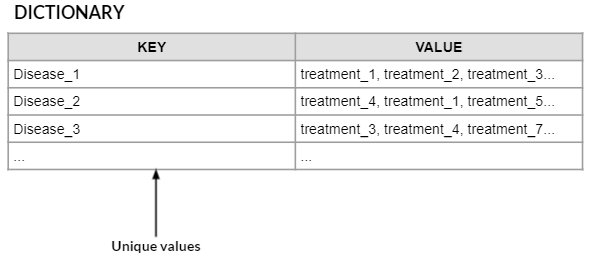

In [50]:
from collections import defaultdict

def build_disease_treatment_dict_clean(sentences, pred_labels):
    """
    Builds a dictionary mapping each disease to a set of unique treatments,
    while cleaning and standardizing the disease and treatment strings.

    Args:
        sentences (list of list of str): Tokenized sentences.
        pred_labels (list of list of str): Corresponding predicted labels for each token.

    Returns:
        dict: A dictionary where keys are cleaned disease names and values are
              sorted lists of unique, cleaned treatment names.
    """
    # Use defaultdict of sets to avoid duplicate treatments per disease
    disease_treatment_dict = defaultdict(set)

    # Process each sentence along with its predicted labels
    for sent_tokens, sent_labels in zip(sentences, pred_labels):
        current_disease_tokens = []   # Accumulates tokens for current disease entity
        current_treatment_tokens = [] # Accumulates tokens for current treatment entity
        diseases = []                 # List to hold extracted disease entities in this sentence
        treatments = []               # List to hold extracted treatment entities in this sentence

        # Iterate token-by-token with corresponding label
        for token, label in zip(sent_tokens, sent_labels):
            if label == 'D':
                # If label is Disease, append token to current disease tokens
                current_disease_tokens.append(token)

                # If treatment tokens have accumulated before, add them to treatments and reset
                if current_treatment_tokens:
                    treatments.append(' '.join(current_treatment_tokens))
                    current_treatment_tokens = []

            elif label == 'T':
                # If label is Treatment, append token to current treatment tokens
                current_treatment_tokens.append(token)

                # If disease tokens have accumulated before, add them to diseases and reset
                if current_disease_tokens:
                    diseases.append(' '.join(current_disease_tokens))
                    current_disease_tokens = []

            else:
                # If label is neither D nor T (e.g., 'O' or other),
                # finalize any ongoing disease or treatment entity extraction
                if current_disease_tokens:
                    diseases.append(' '.join(current_disease_tokens))
                    current_disease_tokens = []

                if current_treatment_tokens:
                    treatments.append(' '.join(current_treatment_tokens))
                    current_treatment_tokens = []

        # Add any remaining tokens at the end of the sentence
        # This finalize and save any unfinished disease or treatment entity from the sentence after all tokens have been processed.
        if current_disease_tokens:
            diseases.append(' '.join(current_disease_tokens))
        if current_treatment_tokens:
            treatments.append(' '.join(current_treatment_tokens))

        # Clean and standardize extracted diseases and treatments, then update dictionary
        for disease in diseases:
            disease_clean = disease.strip().lower()

            # Keep disease uppercase if acronym, otherwise title-case it
            disease_clean = disease_clean.upper() if disease_clean.isupper() else disease_clean.title()

            for treatment in treatments:
                treatment_clean = treatment.strip().lower()
                treatment_clean = treatment_clean.title()  # Title case treatments

                # Add cleaned treatment to the disease's set if not empty
                if treatment_clean:
                    disease_treatment_dict[disease_clean].add(treatment_clean)

    # Convert sets to sorted lists and remove any entries with empty treatment lists
    final_dict = {
        disease: sorted(list(treatments))
        for disease, treatments in disease_treatment_dict.items()
        if treatments
    }

    return final_dict


def print_formatted_dict(disease_treatment_dict):
    """
    Nicely prints the disease-treatment dictionary in a formatted table style.

    Args:
        disease_treatment_dict (dict): Dictionary with diseases as keys and
                                       list of treatments as values.
    """
    print("\nDICTIONARY\n")
    print(f"{'KEY':<25}VALUE")
    print("-" * 80)

    # Sort by disease name for consistent output
    for disease, treatments in sorted(disease_treatment_dict.items()):
        # Join list of treatments as a comma-separated string
        print(f"{disease:<25}{', '.join(treatments)}")


In [51]:
# Build and clean the dictionary
disease_treatment_dict_cleaned = build_disease_treatment_dict_clean(test_sentences, y_pred)

# Print formatted dictionary
print_formatted_dict(disease_treatment_dict_cleaned)


DICTIONARY

KEY                      VALUE
--------------------------------------------------------------------------------
Abdominal Pain           Thoracic Paravertebral Block ( Tpvb )
Acoustic Neuroma         Stereotactic Radiosurgery
Acute Cerebral Ischemia  Antiplatelet Therapy
Acute Colonic Pseudo-ObstructionNeostigmine
Acute Migraine Treatment Sumatriptan
Acute Myocardial InfarctionThrombolytic Therapy, Thrombolytic Treatment
Acute Nasopharyngitis ( Anp )Antibiotic Treatment
Acute Occlusion Of The Middle Cerebral ArteryThrombolytic Therapy
Acute Rejection Episode  Therapy With Extracorporeal Photopheresis
Adenocarcinoma           Resection
Adhd                     Methylphenidate
Advanced Non -- Small-Cell Lung CancerPaclitaxel Plus Carboplatin, Vinorelbine Plus Cisplatin ( Vc )
Advanced Nsclc           Combination Chemotherapy Of Cisplatin , Ifosfamide And Irinotecan With Rhg-Csf Support
Advanced Renal Cell CarcinomaInterferon Alfa-N1 , Interferon Alfa-2A , And Interferon Alfa

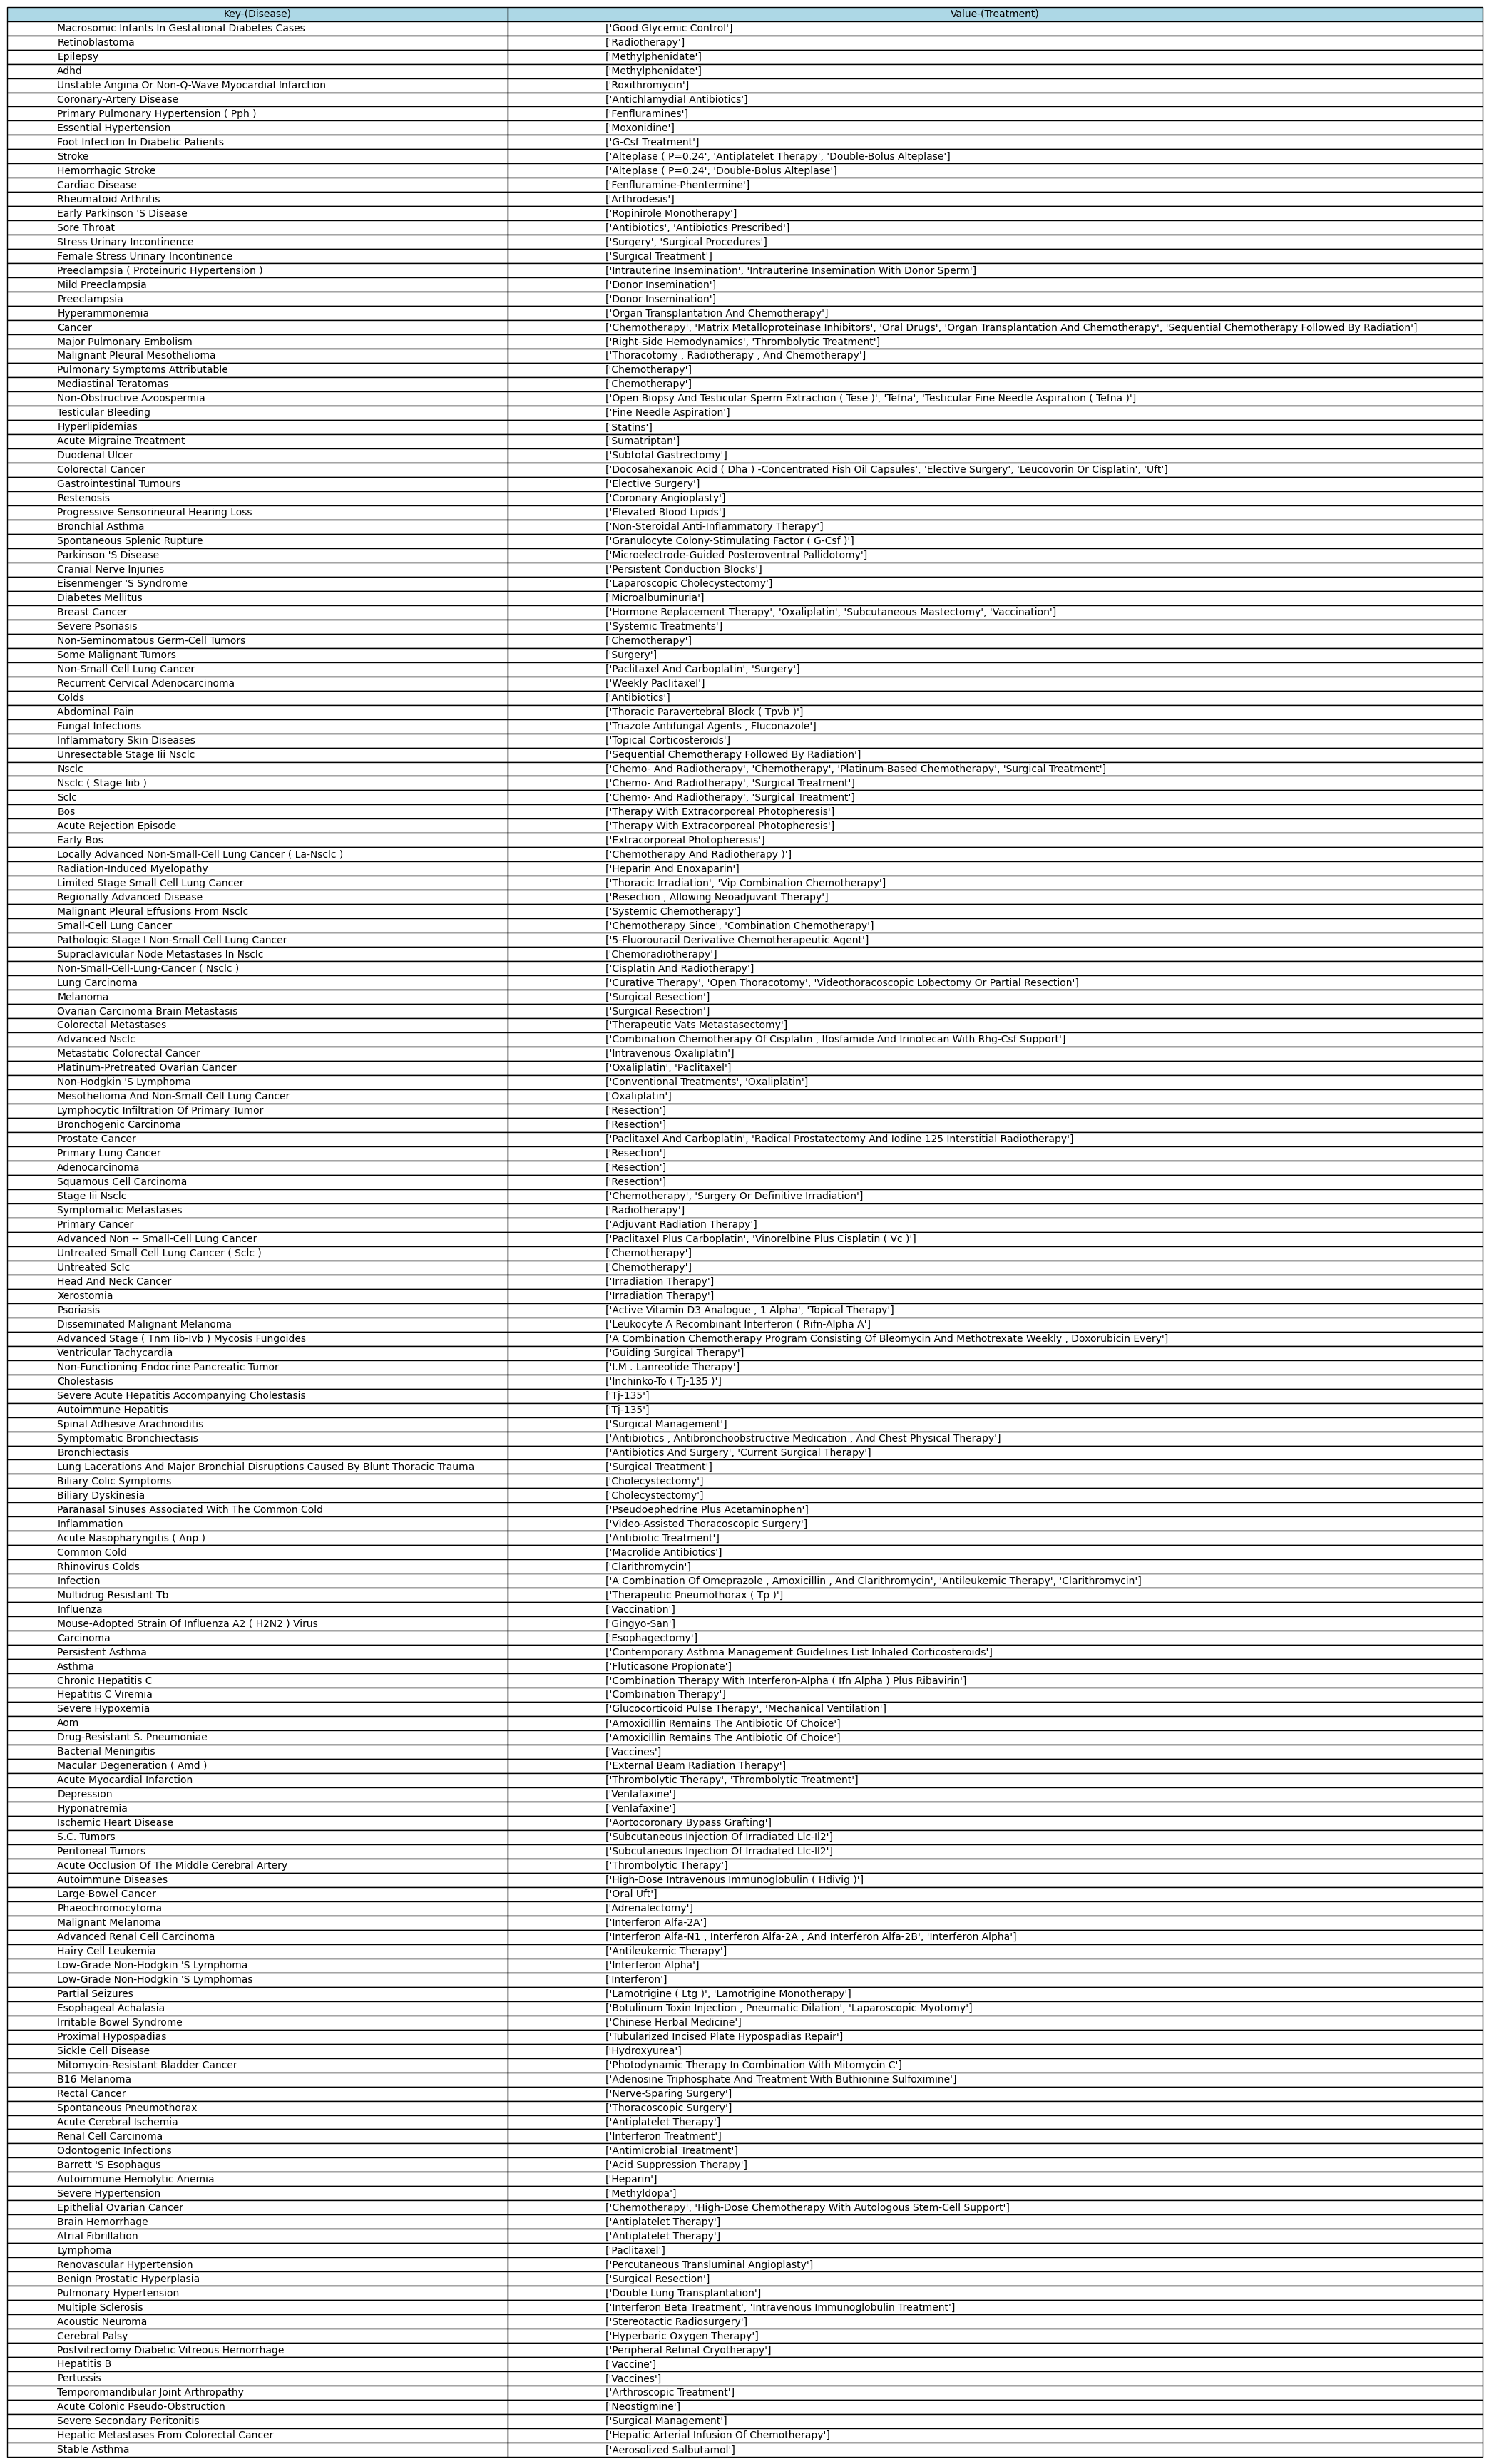

In [52]:
# visualizing the disease_treatment_dict_cleaned as image table 
# Convert dictionary to a DataFrame
df = pd.DataFrame(list(disease_treatment_dict_cleaned.items()), columns=['Key-(Disease)', 'Value-(Treatment)'])

# Set up the figure size
plt.figure(figsize=(12, len(df)*0.2))  # Adjust height dynamically based on number of rows

# Hide axes
plt.axis('off')

# Create table plot
table = plt.table(cellText=df.values,
                  colLabels=df.columns,
                  cellLoc='left',
                  loc='center',
                  colColours=["lightblue"]*2)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df.columns))))

plt.tight_layout()
plt.show()


### Predict the treatment for the disease name: 'hereditary retinoblastoma'

In [54]:
def get_treatment_matches(query_disease, disease_treatment_dict):
    """
    Searches for diseases in the dictionary that match the query disease,
    returning those diseases and their treatments.

    Matching strategy:
    1. Check if the query is a substring of any disease or vice versa.
    2. If no substring match is found, try matching based on shared words.

    Args:
        query_disease (str): The disease name to search for.
        disease_treatment_dict (dict): Dictionary with diseases as keys and list of treatments as values.

    Returns:
        list of tuples: Each tuple contains a matched disease string and its treatments list.
    """

    results = []

    # Convert the query disease to lowercase for case-insensitive matching
    query_lower = query_disease.lower()

    # First attempt: substring matching (query inside disease or disease inside query)
    for disease, treatments in disease_treatment_dict.items():
        disease_lower = disease.lower()
        if query_lower in disease_lower or disease_lower in query_lower:
            results.append((disease, treatments))

    # If no matches found via substring matching, try partial word matching
    if not results:
        # Split the query and disease names into sets of words
        query_words = set(query_lower.split())
        for disease, treatments in disease_treatment_dict.items():
            disease_words = set(disease.lower().split())

            # Find common words between query and disease name
            common_words = query_words.intersection(disease_words)

            # If there are any common words, consider it a match
            if common_words:
                results.append((disease, treatments))

    return results

In [55]:
# Predicting the treatment for a given disease name: 'hereditary retinoblastoma'
query = 'hereditary retinoblastoma'

# Use the function to find diseases matching the query and their treatments
matches = get_treatment_matches(query, disease_treatment_dict_cleaned)

# Check if any matches were found
if matches:
    print(f"Matches for '{query}':")
    # Iterate over each matched disease and its treatments
    for disease, treatments in matches:
        print(f"  - Disease: '{disease}'")
        print(f"    Treatments: {treatments}")
else:
    # Inform user if no matches were found
    print(f"No close matches found for '{query}'.")


Matches for 'hereditary retinoblastoma':
  - Disease: 'Retinoblastoma'
    Treatments: ['Radiotherapy']


#### Observation/Result:

- For the query disease **"hereditary retinoblastoma"**, the model found a close match with the disease **"Retinoblastoma"** in the dictionary.  
- The associated treatment identified is **Radiotherapy**.

This suggests that the matching function effectively captures relevant disease variants and returns meaningful treatment options even when the exact query term isn't present.  
Such approximate matching can be valuable for real-world scenarios where terminology may vary or be incomplete.